Importing libraries

In [101]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

Loading Data

In [20]:
# Published XLSX file URL
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRD0PYPQnWr-BgDRS1wKNFQ3rNFK9VhsICkAHFQs-0QG-2FfJ7CJiGXYo2vjoKTBThCKxsu6jEUKWBK/pub?output=xlsx"

# Load all sheets into a dictionary: keys are sheet names, values are DataFrames
sheets_dict = pd.read_excel(url, sheet_name=None)

In [34]:
# Create a dictionary to hold just the second column from each sheet
data = {}
for stock, df in sheets_dict.items():
    # Extract the second column (index 1) and ignore the first column (dates)
    data[stock] = df.iloc[:, 1]

# Create a new DataFrame with each key as a column
result = pd.DataFrame(data)

In [ ]:
print(result.head())

shape = np.shape(result)
n = shape[0]
p = shape[1]

prices = result.to_numpy()

     AAPL    MSFT    AMZN    NVDA   GOOGL    TSLA    META   BRK.B     UNH
0  226.05  418.47  177.06  124.58  162.96  216.12  527.42  444.51  577.68
1  226.84  416.79  177.04  129.37  165.62  220.32  528.00  453.38  584.51
2  229.00  417.14  178.50  119.37  163.38  214.11  521.31  475.92  590.20
3  220.82  401.70  171.39  102.83  150.92  210.73  500.27  459.42  596.88
4  222.50  430.59  186.49  119.10  157.46  230.29  524.62  447.61  594.32


In [41]:
returns = np.zeros((n-1,p))

for i in range(1, n):
    for j in range(p):
        returns[i - 1, j] = (prices[i, j] - prices[i - 1, j]) / prices[i - 1, j]

risk_free_annual = 4.80/100
risk_free_weekly = (1+risk_free_annual)**(1/52) - 1

excess_returns = (returns - risk_free_weekly).T

In [52]:
f = np.mean(excess_returns, axis=1, keepdims=True)

demeaned_returns = excess_returns - f

In [74]:
sample_cov = (demeaned_returns @ demeaned_returns.T) / (n-1)

print(sample_cov)

[[ 8.94027209e-04  4.53925758e-05  1.77549589e-04 -9.86330747e-05
   3.42692384e-04  6.00115835e-04  2.64409485e-04  1.24348802e-04
  -1.48328492e-04]
 [ 4.53925758e-05  8.16279476e-04  6.12304288e-04  1.19284128e-03
   3.77809096e-04  1.35928192e-03  3.47782562e-04 -4.56190981e-05
  -1.26070526e-04]
 [ 1.77549589e-04  6.12304288e-04  1.19751681e-03  7.27252816e-04
   8.25707108e-04  9.03361078e-04  6.56141976e-04 -1.78214183e-05
  -1.19622195e-05]
 [-9.86330747e-05  1.19284128e-03  7.27252816e-04  4.72280760e-03
   2.08648104e-04  1.19634540e-03  6.01172888e-04  6.77935874e-06
   1.05014245e-04]
 [ 3.42692384e-04  3.77809096e-04  8.25707108e-04  2.08648104e-04
   1.34752131e-03  1.46983920e-03  4.54113893e-04 -4.97969276e-05
  -2.54603270e-05]
 [ 6.00115835e-04  1.35928192e-03  9.03361078e-04  1.19634540e-03
   1.46983920e-03  8.81731645e-03  5.78445061e-04 -3.69058391e-05
   4.49046794e-05]
 [ 2.64409485e-04  3.47782562e-04  6.56141976e-04  6.01172888e-04
   4.54113893e-04  5.7844506

In [94]:
V_inv = np.linalg.inv(sample_cov)
e = np.ones(p)

numer = V_inv @ e

denom = e.T @ numer

h_c = numer / denom

return_c = np.dot(h_c,f).item()
var_c = 1/denom

std_c = math.sqrt(var_c)

var_stocks = np.diag(sample_cov)

In [98]:
# Annualize portfolio C values:
annual_return_c = (1 + return_c)**52 - 1  
annual_var_c    = 52 * var_c
annual_std_c    = np.sqrt(52) * std_c
annual_var_stocks = 52 * var_stocks

Results

In [ ]:
print("Holdings Vector (Portfolio C): ", h_c)

print("Return of Portfolio C: ", return_c)

print("Variance and Standard Deviation of Portfolio C: ", var_c, std_c)

print("Variances of the Stocks: ", var_stocks)

print("Fully Invested?: ", np.sum(h_c))

Holdings Vector (Portfolio C):  [ 0.16251095  0.45315148 -0.12565407 -0.05323164  0.11548928 -0.06245771
  0.03863743  0.30379426  0.16776001]
Return of Portfolio C:  -0.0020979114049176598
Variance and Standard Deviation of Portfolio C:  0.00017400389594736255 0.013191053632949968
Variances of the Stocks:  [0.00089403 0.00081628 0.00119752 0.00472281 0.00134752 0.00881732
 0.00134495 0.00048922 0.00124369]
Fully Invested?:  1.0000000000000002


Plotting and Data Visualization

In [ ]:
# Choose the factor to factor out (here we choose 1e-5 for display)
factor = 1e-5

# Scale the matrix by the factor
scaled_matrix = sample_cov / factor

def matrix_to_latex_scaled(matrix, factor_str="10^{-5}"):
    rows = []
    for row in matrix:
        # Format each element with 2 decimal places (in display units)
        formatted_row = " & ".join(f"{val:.2f}" for val in row)
        rows.append(formatted_row)
    body = " \\\\\n".join(rows)
    # Construct the bmatrix and add a note about the factor
    latex_matrix = f"\\begin{{bmatrix}}\n{body}\n\\end{{bmatrix}}"
    return latex_matrix

# Generate the LaTeX code for the scaled matrix
latex_matrix = matrix_to_latex_scaled(scaled_matrix)

# Final LaTeX output
latex_output = f"$$V = 10^{{-5}} \\cdot {latex_matrix}$$\n\n% (Note: Multiply the entries in the matrix by 10^-5 to obtain the original values.)"

print(latex_output)

$$V = 10^{-5} \cdot \begin{bmatrix}
89.40 & 4.54 & 17.75 & -9.86 & 34.27 & 60.01 & 26.44 & 12.43 & -14.83 \\
4.54 & 81.63 & 61.23 & 119.28 & 37.78 & 135.93 & 34.78 & -4.56 & -12.61 \\
17.75 & 61.23 & 119.75 & 72.73 & 82.57 & 90.34 & 65.61 & -1.78 & -1.20 \\
-9.86 & 119.28 & 72.73 & 472.28 & 20.86 & 119.63 & 60.12 & 0.68 & 10.50 \\
34.27 & 37.78 & 82.57 & 20.86 & 134.75 & 146.98 & 45.41 & -4.98 & -2.55 \\
60.01 & 135.93 & 90.34 & 119.63 & 146.98 & 881.73 & 57.84 & -3.69 & 4.49 \\
26.44 & 34.78 & 65.61 & 60.12 & 45.41 & 57.84 & 134.50 & -1.62 & 14.62 \\
12.43 & -4.56 & -1.78 & 0.68 & -4.98 & -3.69 & -1.62 & 48.92 & 16.71 \\
-14.83 & -12.61 & -1.20 & 10.50 & -2.55 & 4.49 & 14.62 & 16.71 & 124.37
\end{bmatrix}$$

% (Note: Multiply the entries in the matrix by 10^-5 to obtain the original values.)


In [78]:
stocks = ["AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "TSLA", "META", "BRK.B", "UNH"]

# Multiply h_c by 100 to convert to percentages
h_c_percentage = h_c * 100

def vector_to_latex_with_names(vector, names):
    rows = []
    for name, value in zip(names, vector):
        # Format each entry: "NAME: value%" with three decimals
        formatted_entry = f"\\text{{{name}}}: {value:.3f}\\%"
        rows.append(formatted_entry)
    # Join the rows with LaTeX line breaks (\\\\)
    body = " \\\\\n".join(rows)
    # Wrap in a bmatrix environment to produce a column vector
    latex_vector = "\\begin{bmatrix}\n" + body + "\n\\end{bmatrix}"
    return latex_vector

# Generate the LaTeX string for the holdings vector
latex_vector = vector_to_latex_with_names(h_c_percentage, stocks)

# Final LaTeX output with the equation for h_c
latex_output = f"$$ h_c = {latex_vector} $$"

print(latex_output)

$$ h_c = \begin{bmatrix}
\text{AAPL}: 16.251\% \\
\text{MSFT}: 45.315\% \\
\text{AMZN}: -12.565\% \\
\text{NVDA}: -5.323\% \\
\text{GOOGL}: 11.549\% \\
\text{TSLA}: -6.246\% \\
\text{META}: 3.864\% \\
\text{BRK.B}: 30.379\% \\
\text{UNH}: 16.776\%
\end{bmatrix} $$


In [100]:
# ---------------------------
# Table 1: Portfolio C Statistics
# ---------------------------
table1 = f"""
\\begin{{table}}[ht]
\\centering
\\begin{{tabular}}{{lcc}}
\\hline
Statistic & Weekly & Annualized \\\\
\\hline
Return & ${return_c:.6f}$ & ${annual_return_c:.6f}$ \\\\
Variance & ${var_c:.6f}$ & ${annual_var_c:.6f}$ \\\\
Standard Deviation & ${std_c:.6f}$ & ${annual_std_c:.6f}$ \\\\
\\hline
\\end{{tabular}}
\\caption{{Portfolio C: Weekly and Annualized Statistics}}
\\end{{table}}
""".strip()

# ----------------------------------------------------
# Table 2: Individual Stocks (Weekly & Annual Variance)
# ----------------------------------------------------
rows = "\n".join(
    f"{stock} & {w_var:.6f} & {a_var:.6f} \\\\"
    for stock, w_var, a_var in zip(stocks, var_stocks, annual_var_stocks)
)

table2 = f"""
\\begin{{table}}[ht]
\\centering
\\begin{{tabular}}{{lcc}}
\\hline
Stock & Weekly Variance & Annual Variance \\\\
\\hline
{rows}
\\hline
\\end{{tabular}}
\\caption{{Weekly and Annualized Variances for Individual Stocks}}
\\end{{table}}
""".strip()

print("LaTeX code for Portfolio C Statistics Table:\n")
print(table1)
print("\nLaTeX code for Individual Stocks Variances Table:\n")
print(table2)

LaTeX code for Portfolio C Statistics Table:

\begin{table}[ht]
\centering
\begin{tabular}{lcc}
\hline
Statistic & Weekly & Annualized \\
\hline
Return & $-0.002098$ & $-0.103454$ \\
Variance & $0.000174$ & $0.009048$ \\
Standard Deviation & $0.013191$ & $0.095122$ \\
\hline
\end{tabular}
\caption{Portfolio C: Weekly and Annualized Statistics}
\end{table}

LaTeX code for Individual Stocks Variances Table:

\begin{table}[ht]
\centering
\begin{tabular}{lcc}
\hline
Stock & Weekly Variance & Annual Variance \\
\hline
AAPL & 0.000894 & 0.046489 \\
MSFT & 0.000816 & 0.042447 \\
AMZN & 0.001198 & 0.062271 \\
NVDA & 0.004723 & 0.245586 \\
GOOGL & 0.001348 & 0.070071 \\
TSLA & 0.008817 & 0.458500 \\
META & 0.001345 & 0.069938 \\
BRK.B & 0.000489 & 0.025439 \\
UNH & 0.001244 & 0.064672 \\
\hline
\end{tabular}
\caption{Weekly and Annualized Variances for Individual Stocks}
\end{table}


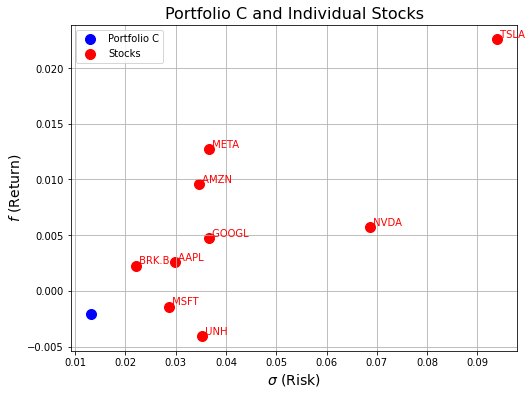

In [104]:
# Compute the standard deviations for stocks from their variances
sigma_stocks = np.sqrt(var_stocks)

# --- Create the Plot ---
plt.figure(figsize=(8, 6))

# Plot Portfolio C as a blue dot
plt.scatter(std_c, return_c, color='blue', s=100, label='Portfolio C')

# Plot individual stocks as red dots
plt.scatter(sigma_stocks, f, color='red', s=100, label='Stocks')

# Annotate each red dot with its corresponding stock name
for x, y, name in zip(sigma_stocks, f, stocks):
    plt.text(x, y, f" {name}", fontsize=10, color='red', verticalalignment='bottom')

# Label the axes using LaTeX formatting
plt.xlabel(r'$\sigma$ (Risk)', fontsize=14)
plt.ylabel(r'$f$ (Return)', fontsize=14)
plt.title('Portfolio C and Individual Stocks', fontsize=16)
plt.legend()
plt.grid(True)

plt.show()